## NFL BIG DATA BOWL 2K26
### Download link: https://www.kaggle.com/competitions/nfl-big-data-bowl-2026-prediction/data

In [94]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist

# plt.style.use("seaborn-v0_8-whitegrid")


In [96]:
BASE_TRAIN = "./nfl-big-data-bowl-2026-prediction/train"
# loading the data.
df = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob(f"{BASE_TRAIN}/input_*.csv"))],
    ignore_index=True
)

print(df.shape)   # no. of rows and cols.
df.head()


(4880579, 23)


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


## Statistical Analysis

In [99]:
df.shape

(4880579, 23)

In [98]:
df.head()  # top five rows for examine the data.

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


In [100]:
df.describe()    # statistical analysis about data.   

,game_id,play_id,nfl_id,frame_id,absolute_yardline_number,player_weight,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
count,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06
mean,2.023155e+09,2.196409e+03,4.955890e+04,1.613179e+01,6.055045e+01,2.112783e+02,6.050074e+01,2.681190e+01,3.019878e+00,2.118335e+00,1.804972e+02,1.815366e+02,1.164147e+01,6.051581e+01,2.663766e+01
std,2.011405e+05,1.246426e+03,5.210338e+03,1.113008e+01,2.305935e+01,2.217747e+01,2.348919e+01,1.000620e+01,2.227939e+00,1.415794e+00,1.007162e+02,9.800912e+01,5.331537e+00,2.529643e+01,1.543814e+01
min,2.023091e+09,5.400000e+01,3.084200e+04,1.000000e+00,1.100000e+01,1.530000e+02,4.100000e-01,6.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,-5.260000e+00,-3.910000e+00
25%,2.023101e+09,1.150000e+03,4.519800e+04,8.000000e+00,4.100000e+01,1.950000e+02,4.263000e+01,1.899000e+01,1.090000e+00,1.010000e+00,9.091000e+01,9.174000e+01,8.000000e+00,4.261000e+01,1.330000e+01
50%,2.023111e+09,2.171000e+03,5.241300e+04,1.500000e+01,6.100000e+01,2.070000e+02,6.041000e+01,2.685000e+01,2.720000e+00,1.920000e+00,1.795600e+02,1.801400e+02,1.000000e+01,6.051000e+01,2.647000e+01
75%,2.023121e+09,3.246000e+03,5.450000e+04,2.200000e+01,8.000000e+01,2.250000e+02,7.823000e+01,3.462000e+01,4.620000e+00,3.040000e+00,2.708300e+02,2.715800e+02,1.400000e+01,7.847000e+01,3.987000e+01
max,2.024011e+09,5.258000e+03,5.667300e+04,1.230000e+02,1.090000e+02,3.580000e+02,1.198600e+02,5.288000e+01,1.253000e+01,1.712000e+01,3.600000e+02,3.600000e+02,9.400000e+01,1.258500e+02,5.733000e+01


In [101]:
df.info()   # information about columns and their crossponding data type.

<class 'pandas.DataFrame'>
RangeIndex: 4880579 entries, 0 to 4880578
Data columns (total 23 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   game_id                   int64  
 1   play_id                   int64  
 2   player_to_predict         bool   
 3   nfl_id                    int64  
 4   frame_id                  int64  
 5   play_direction            str    
 6   absolute_yardline_number  int64  
 7   player_name               str    
 8   player_height             str    
 9   player_weight             int64  
 10  player_birth_date         str    
 11  player_position           str    
 12  player_side               str    
 13  player_role               str    
 14  x                         float64
 15  y                         float64
 16  s                         float64
 17  a                         float64
 18  dir                       float64
 19  o                         float64
 20  num_frames_output         int64  
 

In [102]:
df.isna().sum()   # check whether any column contain null or missing values or not.

game_id                     0
play_id                     0
player_to_predict           0
nfl_id                      0
frame_id                    0
play_direction              0
absolute_yardline_number    0
player_name                 0
player_height               0
player_weight               0
player_birth_date           0
player_position             0
player_side                 0
player_role                 0
x                           0
y                           0
s                           0
a                           0
dir                         0
o                           0
num_frames_output           0
ball_land_x                 0
ball_land_y                 0
dtype: int64

# Column Transformation (column name='player_height',feat-inch  ->  inch.

In [103]:
def height_to_inches(h):   # for converting the height from feat-inch to inch
    try:
        feet, inches = map(int, h.split('-'))
        return feet * 12 + inches
    except:
        return None

In [104]:
features = [
    'player_weight','x','y','s','a',
    'num_frames_output','ball_land_x','ball_land_y'
]   # extracting the relevant features.
# df[features] = np.log1p(df[features])


In [105]:
df['player_height'] = df['player_height'].apply(height_to_inches) 
# apply the height_to_inch fucntion  in player_height column

## Plot the boxplot for analysis of outliers.

/var/folders/90/7bhc4qw17dd0tc8r6137_d040000gn/T/ipykernel_28983/2732888656.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_position', y='s', palette='viridis', order=df['player_position'].value_counts().index)


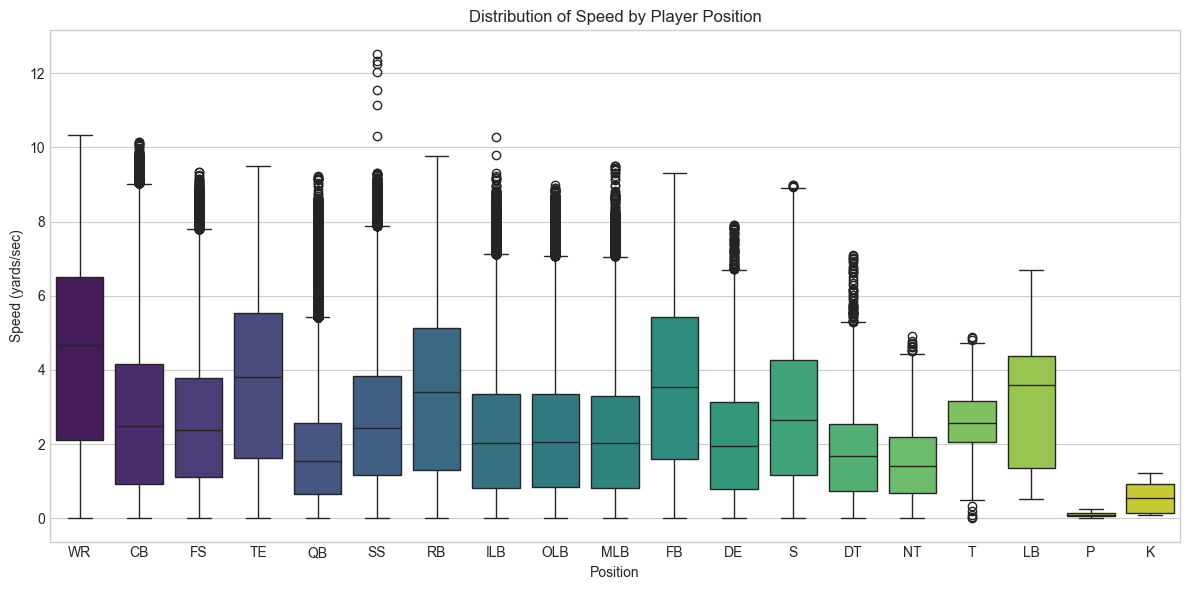

In [106]:
# plot a  box plot between player_position and speed for analysis of outliers.


plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='player_position', y='s', palette='viridis', order=df['player_position'].value_counts().index)
plt.title('Distribution of Speed by Player Position')
plt.xlabel('Position')
plt.ylabel('Speed (yards/sec)')

plt.tight_layout()

## analyze the tracjectories of player 101.

In [ ]:




sample_play_id = df['play_id'].iloc[0]
sample_game_id = df['game_id'].iloc[0]

play_data = df[
    (df['play_id'] == sample_play_id) &
    (df['game_id'] == sample_game_id)
]

plt.figure(figsize=(10, 6))

for nfl_id, p_df in play_data.groupby("nfl_id"):
    plt.plot(
        p_df['x'],
        p_df['y'],
        alpha=0.7,
        label=f"Player {nfl_id}"
    )

plt.title(f'Player Trajectories (Game {sample_game_id}, Play {sample_play_id})')
plt.xlabel('X (Field Length)')
plt.ylabel('Y (Field Width)')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize='small'
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Relation between speed and weight
## Relation between acceleration and weight

In [108]:
player_stats = df.groupby('nfl_id').agg({
    'player_weight': 'first',
    's': 'max',
    'player_position': 'first'
}).rename(columns={'s': 'max_speed'})      


player_stats_acc = df.groupby('nfl_id').agg({
    'player_weight': 'first',
    'a': 'max',
    'player_position': 'first'
}).rename(columns={'a': 'max_acc'})

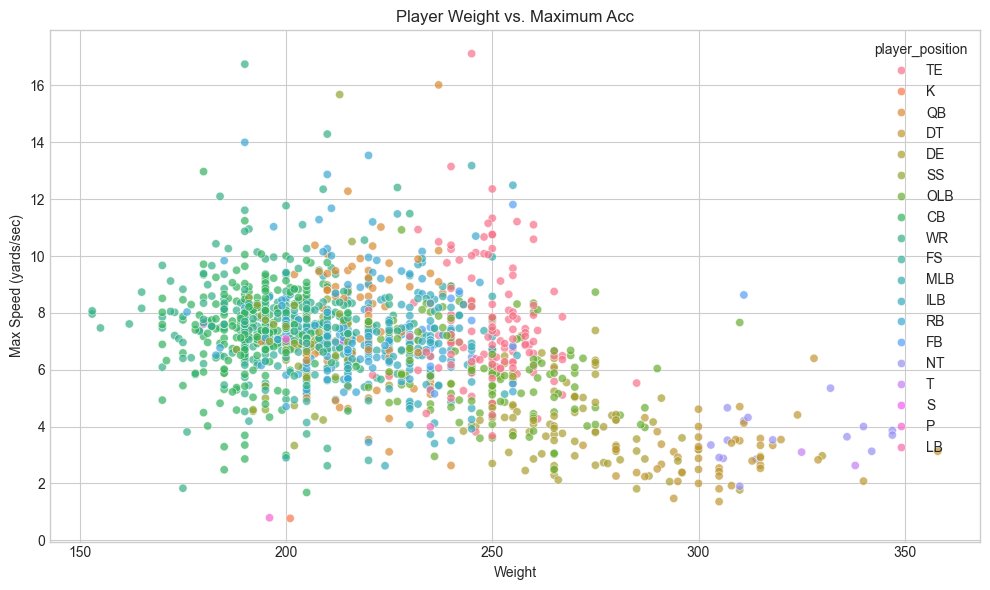

In [109]:
# plot between player_weight and their crosspondig acceleration..
# this plot shows that  if player_weight is large their relative acceleration is low.
# maximum no. of player having a weigth between 175-250.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=player_stats_acc, x='player_weight', y='max_acc', hue='player_position', alpha=0.7)
plt.title('Player Weight vs. Maximum Acc')
plt.xlabel('Weight')
plt.ylabel('Max Speed (yards/sec)')

plt.tight_layout()
plt.savefig('weight_vs_speed.png')

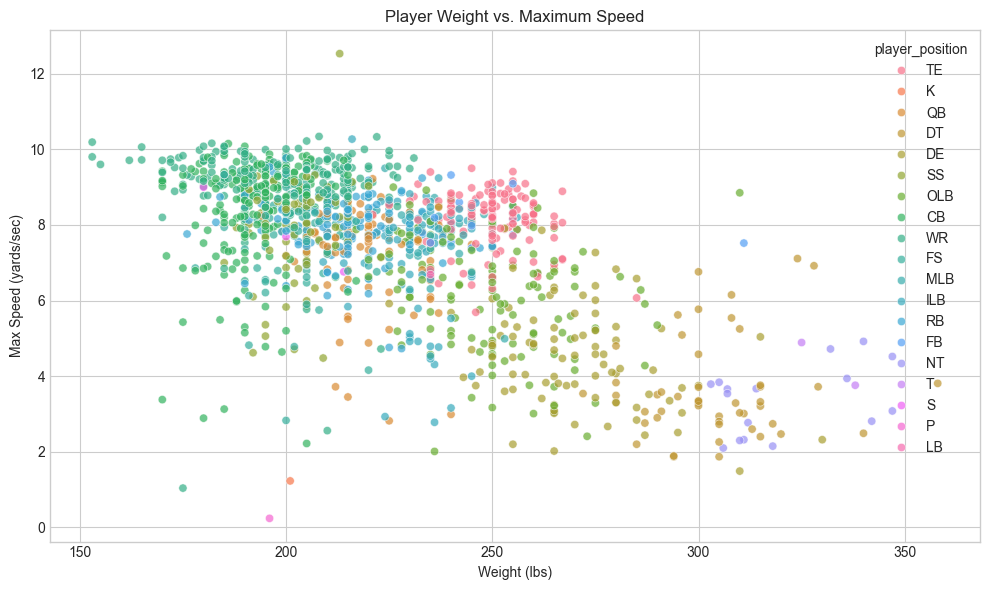

In [110]:
# plot between player_weight and their crosspondig speed.
# this plot shows that  if player_weight is large their relative speed is slow.
# maximum no. of player having a weigth between 175-250

plt.figure(figsize=(10, 6))
sns.scatterplot(data=player_stats, x='player_weight', y='max_speed', hue='player_position', alpha=0.7)
plt.title('Player Weight vs. Maximum Speed')
plt.xlabel('Weight (lbs)')
plt.ylabel('Max Speed (yards/sec)')

plt.tight_layout()
plt.savefig('weight_vs_speed.png')

## Analysis the field density

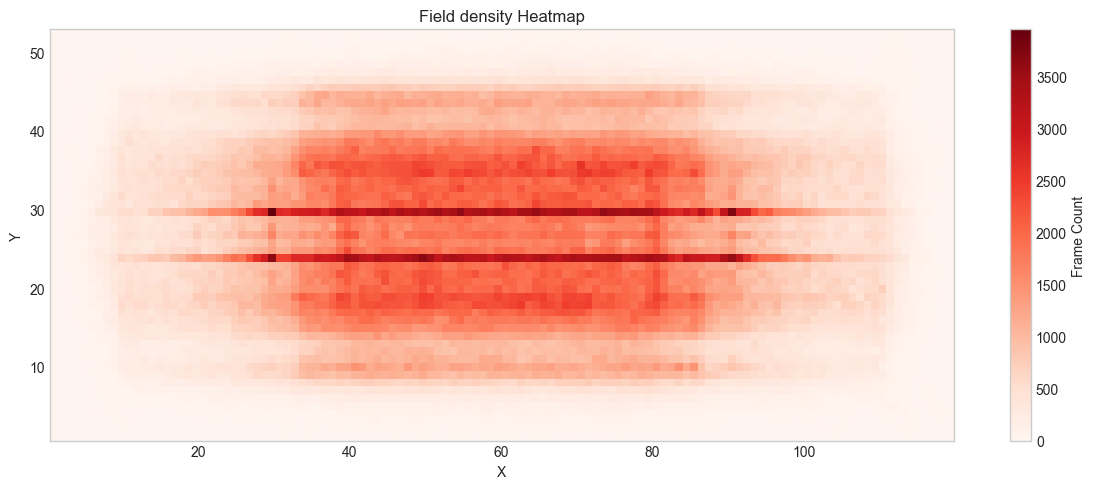

In [111]:
# Each cell shows how many times a player appeared at that location 
# across all frames and plays.
# X-axis → field length
# Y-axis → field width
# Color intensity → frame count (density)

plt.figure(figsize=(12, 5))
plt.hist2d(df['x'], df['y'], bins=[120, 53], cmap='Reds')
plt.colorbar(label='Frame Count')
plt.title('Field density Heatmap')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()

## Corrlation between features

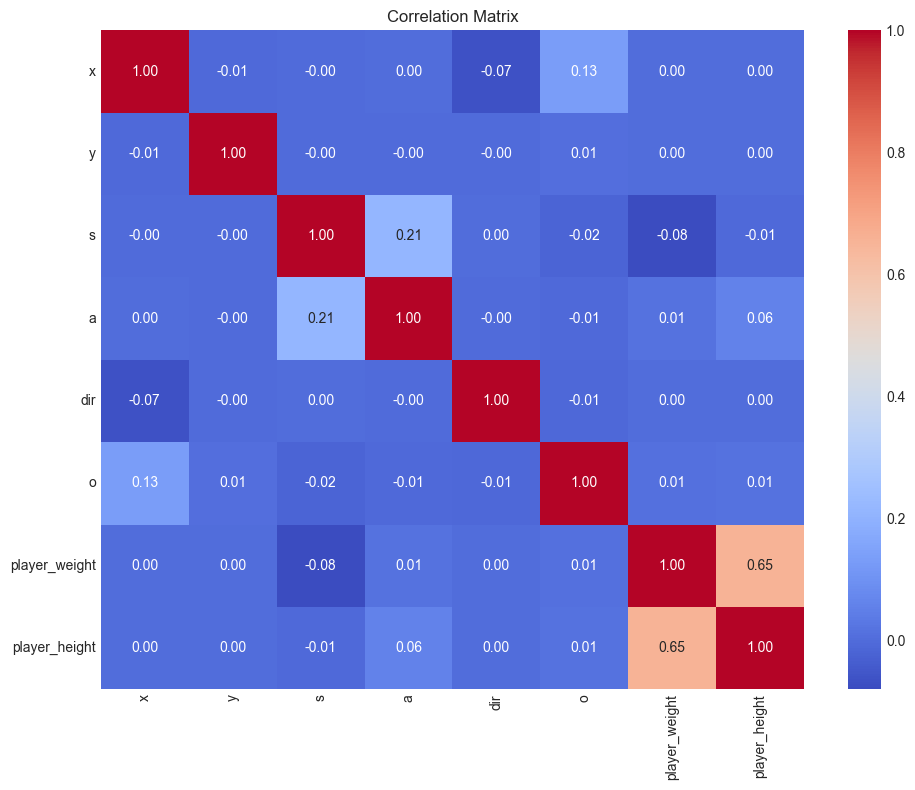

In [112]:
# This heatmap shows pairwise Pearson correlations 
# between numeric player attributes and movement variables.
# +1.0 → strong positive linear relationship
# 0.0 → little to no linear relationship# −1.0 → strong negative linear relationship

plt.figure(figsize=(10, 8))
corr = df[['x', 'y', 's', 'a', 'dir', 'o', 'player_weight', 'player_height']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()

## Calculate the frame distance(difference between player position for each frame.)

In [124]:
df["dx"] = df.groupby("nfl_id")["x"].diff()  # dx is the diffenrece between x cordinates of two frames.
df["dy"] = df.groupby("nfl_id")["y"].diff() # dy is the diffenrece between y cordinates of two frames.
df["frame_dist"] = np.sqrt(df.dx**2 + df.dy**2)

df["dist_to_ball"] = np.sqrt(
    (df.x - df.ball_land_x)**2 + (df.y - df.ball_land_y)**2
)
      # distance between ball corrdiantes and player coordinates. 
df["speed_diff"] = df.groupby(
    ["play_id", "nfl_id"]
)["s"].diff()
df.head()




,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,dir,o,num_frames_output,ball_land_x,ball_land_y,dx,dy,frame_dist,dist_to_ball,speed_diff
0,2023090700,101,False,54527,1,right,42,Bryan Cook,73,1.848747,...,322.40,238.24,1.4088,1.641506,-0.285633,NaN,NaN,NaN,1.819858,NaN
1,2023090700,101,False,54527,2,right,42,Bryan Cook,73,1.848747,...,200.89,236.05,1.4088,1.641506,-0.285633,0.000000,0.000000,0.000000,1.819858,-0.044194
2,2023090700,101,False,54527,3,right,42,Bryan Cook,73,1.848747,...,147.55,240.60,1.4088,1.641506,-0.285633,0.000000,-0.000057,0.000057,1.819801,0.068883
3,2023090700,101,False,54527,4,right,42,Bryan Cook,73,1.848747,...,131.40,244.25,1.4088,1.641506,-0.285633,0.000075,-0.000057,0.000094,1.819742,0.080795
4,2023090700,101,False,54527,5,right,42,Bryan Cook,73,1.848747,...,123.26,244.25,1.4088,1.641506,-0.285633,0.000075,-0.000114,0.000136,1.819627,0.074295


## Speed Distribution over players

Text(0.5, 1.0, 'Speed Distribution')

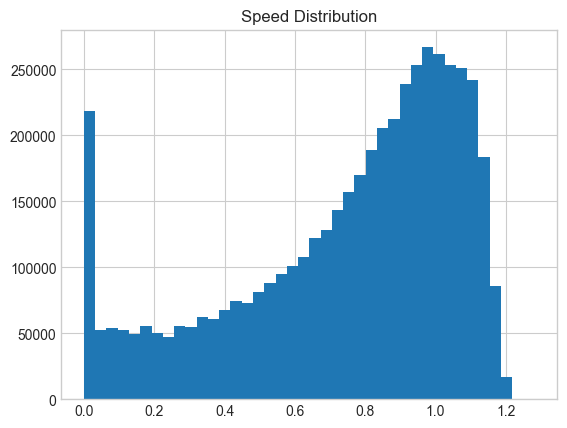

In [125]:
plt.hist(df.s, bins=40)
plt.title("Speed Distribution")    # speed distribution over player count.

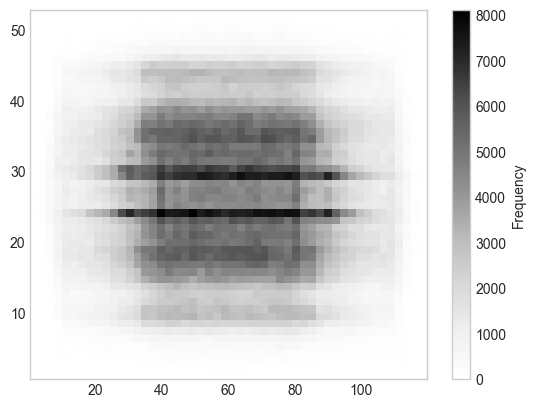

In [69]:
plt.hist2d(df.x, df.y, bins=50)
plt.colorbar(label="Frequency")   

## Capturing a movement direction for a particular person 

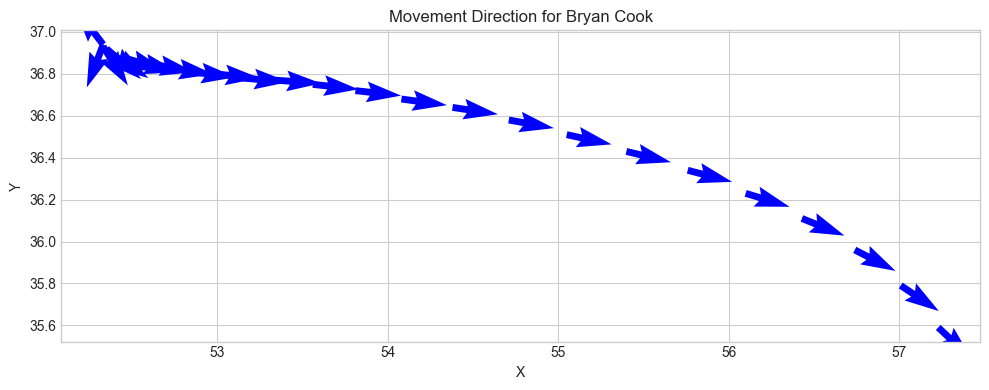

In [70]:
sample_player_id = play_data['nfl_id'].iloc[0]
player_sample = play_data[play_data['nfl_id'] == sample_player_id]

plt.figure(figsize=(10, 4))
rad = np.deg2rad(90 - player_sample['dir'])
u, v = np.cos(rad), np.sin(rad)
plt.quiver(player_sample['x'], player_sample['y'], u, v, color='blue', scale=20)
plt.title(f"Movement Direction for {player_sample['player_name'].iloc[0]}")
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.tight_layout()       # movement direction for bryan cook

## Removing the outliers using column transformation

In [121]:
Features = [
    'player_weight','x','y','s','a',
    'num_frames_output','ball_land_x','ball_land_y'
]

df[Features] = np.log1p(df[Features])
#column transformation for remove the outliers.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


/var/folders/90/7bhc4qw17dd0tc8r6137_d040000gn/T/ipykernel_28983/1366993070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_position', y='s', palette='viridis', order=df['player_position'].value_counts().index)


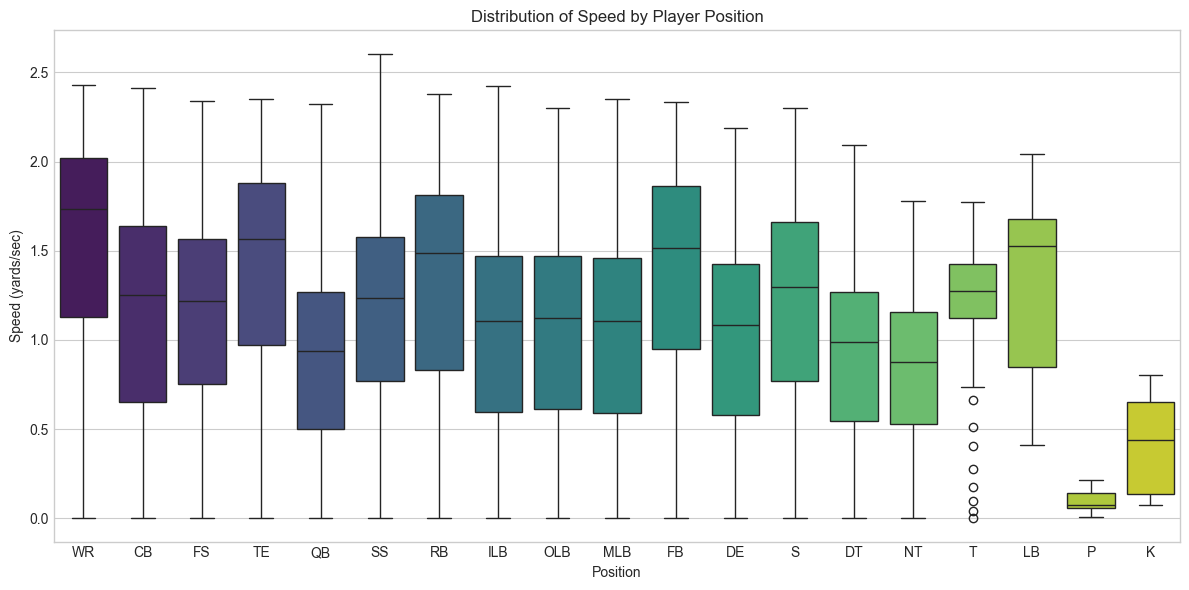

In [118]:

# plot after transformation almost solve the outliers problem.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='player_position', y='s', palette='viridis', order=df['player_position'].value_counts().index)
plt.title('Distribution of Speed by Player Position')
plt.xlabel('Position')
plt.ylabel('Speed (yards/sec)')

plt.tight_layout()

## Normalization of coordinates , orientation , direction

In [126]:
def normalize_direction(df):   # normalization of direction
    df = df.copy()
    left = df["play_direction"] == "left"    # extract the player who is in left direction
    df.loc[left, "x"] = 120 - df.loc[left, "x"]  # convert -x to +x
    df.loc[left, "y"] = 53.3 - df.loc[left, "y"] # similiary for y
    df.loc[left, "dir"] = (df.loc[left, "dir"] + 180) % 360   # change the direction
    df.loc[left, "o"] = (df.loc[left, "o"] + 180) % 360  # change the orientation.
    return df   

df = normalize_direction(df)


## capturing the routes crossponding to the receivers.

In [127]:
receivers = df[
    (df.player_side == "Offense") &
    (df.player_role.isin(["Targeted Receiver", "Other Route Runner"]))
]    # create a new DataFrame receivers for receiver players. receiver should be a offensive player.


# find out all the routes crossponding to the receivers.
# like their depth , width , path_length,and what is the duration.
routes = (
    receivers
    .sort_values("frame_id")
    .groupby(["game_id","play_id","nfl_id"])
    .apply(lambda g: pd.Series({
        "depth": g["x"].max() - g["x"].min(),
        "width": abs(g["y"].iloc[-1] - g["y"].iloc[0]),
        "path_length": np.sqrt(
            g["x"].diff().fillna(0)**2 +
            g["y"].diff().fillna(0)**2
        ).sum(),
        "duration": g.shape[0]
    }))
    .reset_index()
)     

## Minimum distance between offensive player and nearest defender.

In [128]:
# function used for calculation of seperation.seperation means minimum distance between offensive player and nearest defender.
def compute_separation(df):
    offense = df[df.player_side == "Offense"]
    defense = df[df.player_side == "Defense"]

    rows = []

    for (g,p,f), off in offense.groupby(["game_id","play_id","frame_id"]):
        d = defense[
            (defense.game_id==g)&
            (defense.play_id==p)&
            (defense.frame_id==f)
        ]
        if d.empty:
            continue

        dist = cdist(off[["x","y"]], d[["x","y"]])   # cdist a builtin fuction that used for calculating the distance. i use it because it is fast compare to other methods.
        rows.extend([{
            "game_id": g,
            "play_id": p,
            "frame_id": f,
            "nfl_id": off.iloc[i].nfl_id,
            "separation": dist[i].min()
        } for i in range(len(off))])

    return pd.DataFrame(rows)

seperation = compute_separation(df)


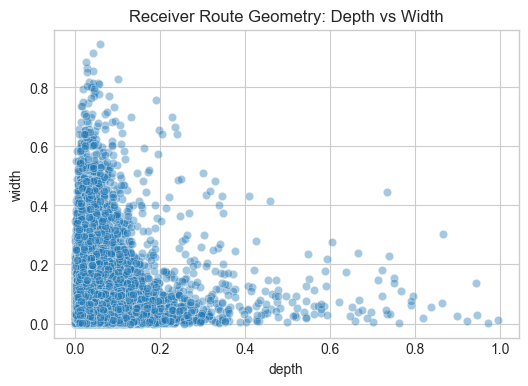

In [129]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=routes, x="depth", y="width", alpha=0.4)
plt.title("Receiver Route Geometry: Depth vs Width")
plt.show()

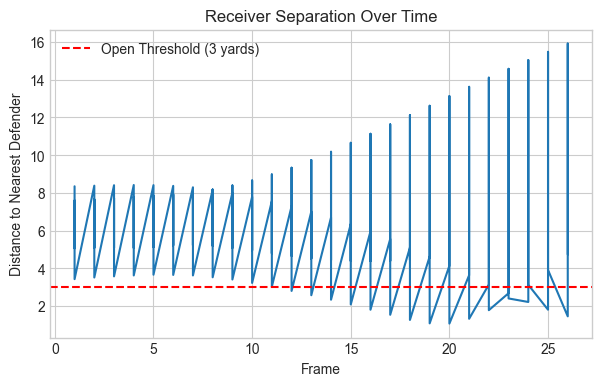

In [130]:
example = separation[
    (separation.game_id == separation.game_id.iloc[0]) &
    (separation.play_id == separation.play_id.iloc[0])
]

plt.figure(figsize=(7,4))
plt.plot(example.frame_id, example.separation)
plt.axhline(3, color="red", linestyle="--", label="Open Threshold (3 yards)")
plt.title("Receiver Separation Over Time")
plt.xlabel("Frame")
plt.ylabel("Distance to Nearest Defender")
plt.legend()
plt.show()


## Computing and analyzing the pressure for passer 

In [131]:
def compute_pressure(df):
    qb = df[df.player_role == "Passer"]
    defense = df[df.player_side == "Defense"]

    rows = []

    for (g,p,f), q in qb.groupby(["game_id","play_id","frame_id"]):
        d = defense[
            (defense.game_id==g)&
            (defense.play_id==p)&
            (defense.frame_id==f)
        ]
        if d.empty:
            continue

        dist = cdist(q[["x","y"]], d[["x","y"]])
        rows.append({
            "game_id": g,
            "play_id": p,
            "frame_id": f,
            "min_pressure": dist.min()
        })

    return pd.DataFrame(rows)

pressure = compute_pressure(df)


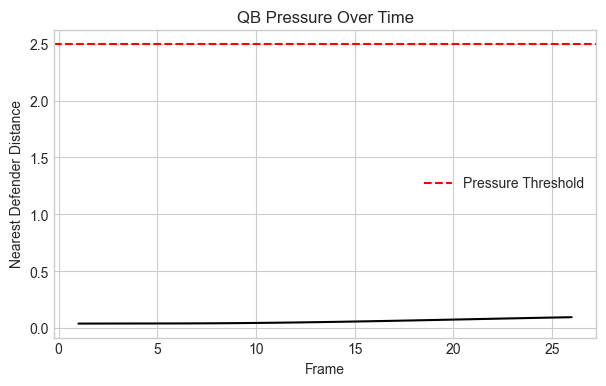

In [132]:
example_p = pressure[
    (pressure.game_id == pressure.game_id.iloc[0]) &
    (pressure.play_id == pressure.play_id.iloc[0])
]

plt.figure(figsize=(7,4))
plt.plot(example_p.frame_id, example_p.min_pressure, color="black")
plt.axhline(2.5, color="red", linestyle="--", label="Pressure Threshold")
plt.title("QB Pressure Over Time")
plt.xlabel("Frame")
plt.ylabel("Nearest Defender Distance")
plt.legend()
plt.show()


## Play summary: grouping the player  on game_id,play_id condiotion is maximum seperation.
## capturing the archtypes

In [133]:
play_summary = (
    separation.groupby(["game_id","play_id"])
    .agg(
        max_sep=("separation","max"),
        sep_time=("frame_id","count")
    )
    .reset_index()
)

play_summary["archetype"] = np.select(
    [
        play_summary.max_sep > 3,
        play_summary.max_sep.between(2,3),
        play_summary.max_sep < 2
    ],
    [
        "Coverage Bust",
        "Tight Window",
        "Perfect Coverage"
    ],
    default="Other"
)


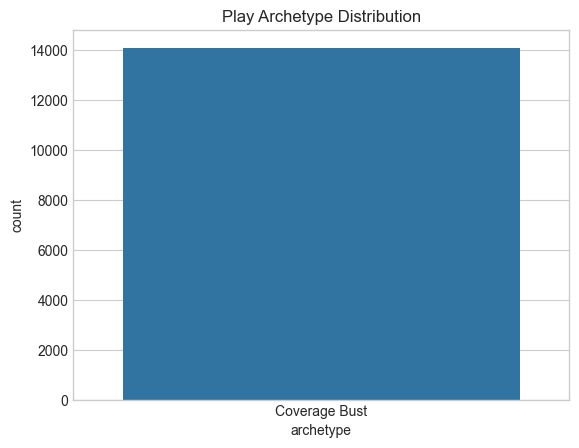

In [134]:
sns.countplot(data=play_summary, x="archetype")
plt.title("Play Archetype Distribution")
plt.show()

## Distribution of QB pressure between players.

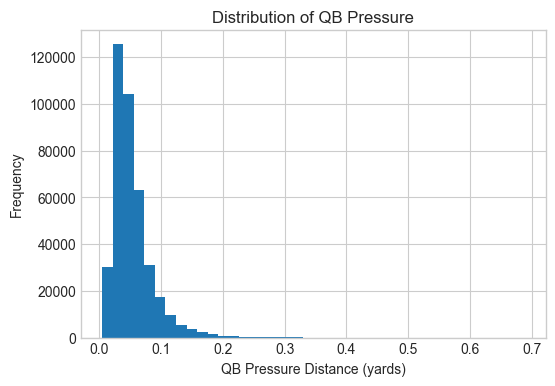

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pressure['min_pressure'].dropna(), bins=40)
plt.xlabel("QB Pressure Distance (yards)")
plt.ylabel("Frequency")
plt.title("Distribution of QB Pressure")
plt.show()

## Distribution of receiver seperation across player

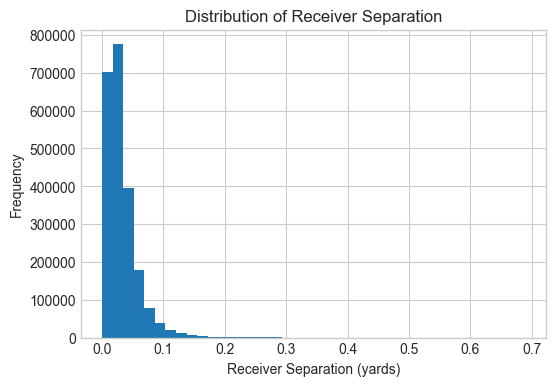

In [142]:
plt.figure(figsize=(6,4))
plt.hist(seperation['separation'].dropna(), bins=40)
plt.xlabel("Receiver Separation (yards)")
plt.ylabel("Frequency")
plt.title("Distribution of Receiver Separation")
plt.show()
